E-commerce Analysis

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [43]:
df = pd.read_csv('online-retail-dataset.csv', encoding='ISO-8859-1')

df.head()
df.info()
print(df.describe())
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max 

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [44]:
df = df.dropna()
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["Month"] = df["InvoiceDate"].dt.to_period("M")

Очистка + первый взгляд на данные

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64


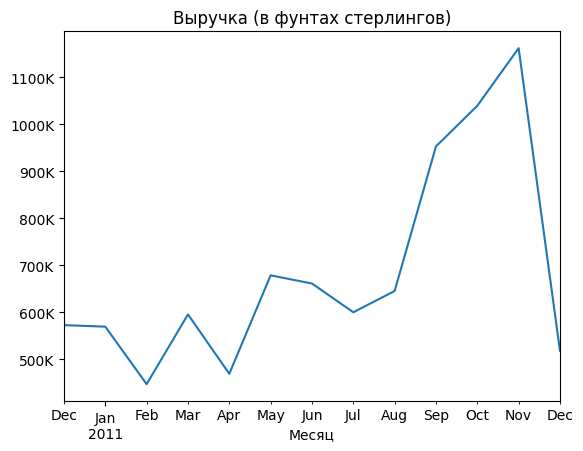

In [45]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()
print(monthly_revenue)

monthly_revenue.index = monthly_revenue.index.to_timestamp()

ax = monthly_revenue.plot()

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))
ax.set_xlabel("Месяц", labelpad=-10)

plt.title("Выручка (в фунтах стерлингов)")
plt.savefig("images/revenue.png")

Видно, что продажи имеют выраженную сезонность: присутствует сильный рост осенью с пиком в ноябре, что может быть связано с подготовкой к праздникам (например, к Рождеству). На первый взгляд также заметно резкое "падение" продаж в декабре, но этот вывод ложный: график просел вовсе не из-за того, что продажи действительно снизились, а потому что в самом датасете предоставлены данные только до середины месяца: до 13 декабря включительно.

In [46]:
daily_revenue = df.groupby(df["InvoiceDate"].dt.date)["Revenue"].sum()
print("Топ дней по продажам:\n", daily_revenue.sort_values(ascending=False).head(), sep="")

avg_check = df.groupby("InvoiceNo")["Revenue"].sum().mean()
print("\nСредний чек:", avg_check)

top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)
print("\nТоп посетителей:\n", top_customers, sep="")

Топ дней по продажам:
InvoiceDate
2011-12-09    184349.28
2011-09-20    103435.81
2011-01-18     87589.11
2011-10-05     74108.43
2011-09-15     71993.67
Name: Revenue, dtype: float64

Средний чек: 480.8659563997409

Топ посетителей:
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64


Мы видим, что выручка сильно варьируется по дням. В отдельные дни наблюдаются резкие пики, что может быть связано с крупными заказами или акциями.

Средний чек составляет около 480£, что может говорить о достаточно крупных заказах и ориентации на оптовых или корпоративных клиентов.

Небольшое количество клиентов приносит значительную долю выручки. Это указывает на зависимость бизнеса от ключевых клиентов.

In [47]:
plt.figure(figsize=(10,6))

df = df[(df["Description"] != "Manual") & (df["Description"] != "POSTAGE")] # удаляем продажи, внесённые вручную и почтовые расходы

top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
RABBIT NIGHT LIGHT                     51346.20
CHILLI LIGHTS                          46286.51
PAPER CHAIN KIT 50'S CHRISTMAS         42660.83
Name: Revenue, dtype: float64


<Figure size 1000x600 with 0 Axes>

В данных присутствуют записи о затратах на доставку и записи, сделанные вручную, которые необходимо было удалить для проведения анализа

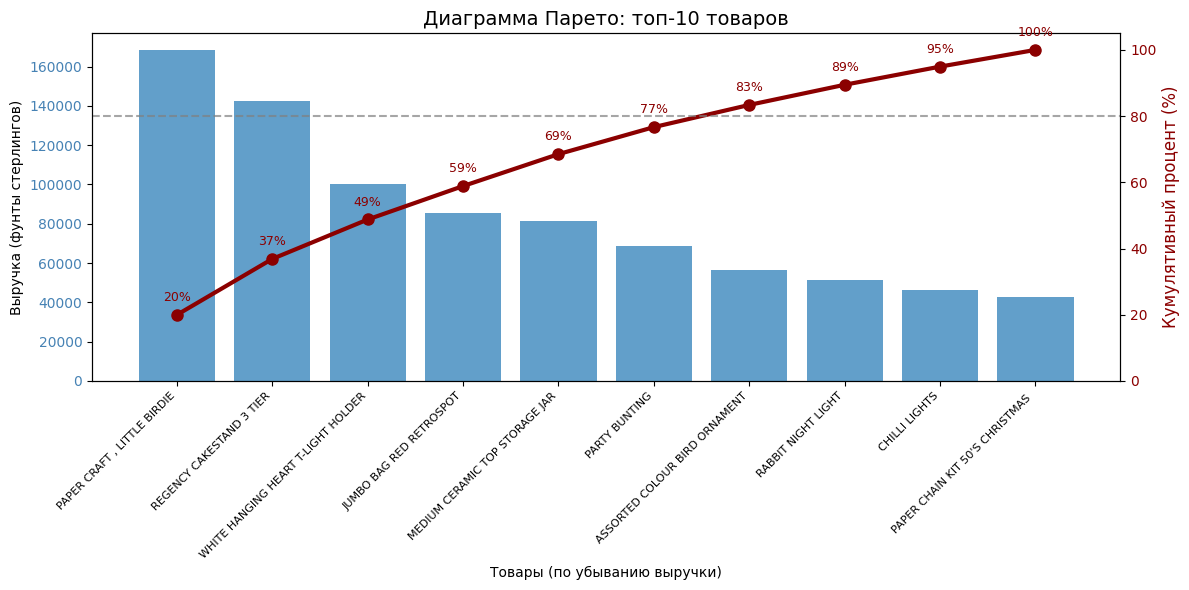

In [48]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

cumulative = (top_products.cumsum() / top_products.sum()) * 100

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(range(len(top_products)), top_products.values, alpha=0.7)
ax.set_xticks(range(len(top_products)))
ax.set_xticklabels(top_products.index, rotation=45, ha='right', fontsize=8)
ax.set_xlabel("Товары (по убыванию выручки)")
ax.set_ylabel("Выручка (фунты стерлингов)")
ax.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax.twinx()
ax2.plot(range(len(top_products)), cumulative, color='darkred', marker='o', linewidth=3, markersize=8)
ax2.set_ylabel("Кумулятивный процент (%)", color='darkred', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.set_ylim(0, 105)

ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for i, (x, y) in enumerate(zip(range(len(top_products)), cumulative)):
    ax2.annotate(f'{y:.0f}%', (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, color='darkred')

plt.title("Диаграмма Парето: топ-10 товаров", fontsize=14)
plt.tight_layout()
plt.savefig("images/pareto_products.png")
plt.show()

Первые 7 товаров из топ-10 обеспечивают 83% выручки от этих десяти товаров. Это прямое проявление принципа Парето (закона 80/20): небольшая часть ассортимента генерирует основную долю продаж.

Компания сильно зависит от ограниченного числа товаров. Проблемы с поставками или снижение спроса на любой из этих 7 товаров могут существенно ударить по общей выручке.
В то же время, это показывает, где сосредоточены основные усилия: поддержание наличия топ-позиций, работа с их ценообразованием и продвижением — ключ к стабильности.

В заключение, как аналитик, хотел бы порекомендовать диверсифицировать клиентскую базу и тщательнее проанализировать причины пиков продаж